<a href="https://colab.research.google.com/github/snehalwath07/Salary_prediction/blob/main/SALARY_PREDICTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("/content/Salary_Dataset_DataScienceLovers.csv")
df

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android
...,...,...,...,...,...,...,...,...
32030,4.7,Expert Solutions,Web Developer,200000,1,Bangalore,Full Time,Web
32031,4,Nextgen Innovation Labs,Web Developer,300000,1,Bangalore,Full Time,Web
32032,4.1,Fresher,Full Stack Web Developer,192000,13,Bangalore,Full Time,Web
32033,4.1,Accenture,Full Stack Web Developer,300000,7,Bangalore,Full Time,Web


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32035 entries, 0 to 32034
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Rating             32035 non-null  object
 1   Company Name       32033 non-null  object
 2   Job Title          32035 non-null  object
 3   Salary             32035 non-null  int64 
 4   Salaries Reported  32035 non-null  object
 5   Location           32035 non-null  object
 6   Employment Status  32035 non-null  object
 7   Job Roles          32034 non-null  object
dtypes: int64(1), object(7)
memory usage: 2.0+ MB


In [ ]:
df.isnull().sum()

,0
Rating,0
Company Name,2
Job Title,0
Salary,0
Salaries Reported,0
Location,0
Employment Status,0
Job Roles,1


In [ ]:
company_name_mode = df['Company Name'].mode()[0]
job_roles_mode = df['Job Roles'].mode()[0]

df['Company Name'].fillna(company_name_mode, inplace=True)
df['Job Roles'].fillna(job_roles_mode, inplace=True)

df.isnull().sum()

/tmp/ipykernel_5089/2692550956.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Company Name'].fillna(company_name_mode, inplace=True)
/tmp/ipykernel_5089/2692550956.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

,0
Rating,0
Company Name,0
Job Title,0
Salary,0
Salaries Reported,0
Location,0
Employment Status,0
Job Roles,0


In [ ]:
for column in df.columns:
  if df[column].dtype == 'object':
    df[column] = df[column].fillna(df[column].mode()[0])
  elif df[column].dtype in ['int64', 'float64']:
    df[column] = df[column].fillna(df[column].mean())
print(df.isnull().sum())

Rating               0
Company Name         0
Job Title            0
Salary               0
Salaries Reported    0
Location             0
Employment Status    0
Job Roles            0
dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for column in df.columns:
  if df[column].dtype == 'object':
    df[column] = le.fit_transform(df[column])

display(df.head())

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,26,8129,29,400000,35,0,1,0
1,35,417,29,400000,35,0,1,0
2,30,9778,29,1000000,35,0,1,0
3,26,8533,29,300000,35,0,1,0
4,34,884,29,600000,35,0,1,0


In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
32030,True
32031,True
32032,True
32033,True


In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop('Salary', axis=1) # All columns except 'Salary'
y = df['Salary'] # 'Salary' column

# Split the data into training and testing sets (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (25628, 7)
Shape of X_test: (6407, 7)
Shape of y_train: (25628,)
Shape of y_test: (6407,)


### Building and Evaluating Regression Models

In [ ]:
from sklearn.neig

# --- 1. K-Nearest Neighbors (KNN) Regressor ---
print("\n--- Training K-Nearest Neighbors (KNN) Regressor ---")
knn_model = KNeighborsRegressor(n_neighbors=5) # Using 5 neighbors as a starting point
knn_model.fit(X_trhbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.naive_bayes import GaussianNB # Gaussian Naive Bayes for continuous data
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Initialize a dictionary to store model results
model_results = {}ain, y_train)
y_pred_knn = knn_model.predict(X_test)

mae_knn = mean_absolute_error(y_test, y_pred_knn)
mse_knn = mean_squared_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mse_knn)
r2_knn = r2_score(y_test, y_pred_knn)

model_results['KNN'] = {'MAE': mae_knn, 'MSE': mse_knn, 'RMSE': rmse_knn, 'R2': r2_knn}

print(f"KNN MAE: {mae_knn:.2f}")
print(f"KNN MSE: {mse_knn:.2f}")
print(f"KNN RMSE: {rmse_knn:.2f}")
print(f"KNN R-squared: {r2_knn:.2f}")

# --- 2. Random Forest Regressor ---
print("\n--- Training Random Forest Regressor ---")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42) # Using 100 estimators
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

model_results['Random Forest'] = {'MAE': mae_rf, 'MSE': mse_rf, 'RMSE': rmse_rf, 'R2': r2_rf}

print(f"Random Forest MAE: {mae_rf:.2f}")
print(f"Random Forest MSE: {mse_rf:.2f}")
print(f"Random Forest RMSE: {rmse_rf:.2f}")
print(f"Random Forest R-squared: {r2_rf:.2f}")

# --- 3. Support Vector Machine (SVM) Regressor ---
print("\n--- Training Support Vector Machine (SVM) Regressor ---")
# SVM can be computationally expensive on large datasets. Scaling might also be needed.
# For now, using default parameters, but may need tuning/scaling for better performance.
svm_model = SVR()
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

mae_svm = mean_absolute_error(y_test, y_pred_svm)
mse_svm = mean_squared_error(y_test, y_pred_svm)
rmse_svm = np.sqrt(mse_svm)
r2_svm = r2_score(y_test, y_pred_svm)

model_results['SVM'] = {'MAE': mae_svm, 'MSE': mse_svm, 'RMSE': rmse_svm, 'R2': r2_svm}

print(f"SVM MAE: {mae_svm:.2f}")
print(f"SVM MSE: {mse_svm:.2f}")
print(f"SVM RMSE: {rmse_svm:.2f}")
print(f"SVM R-squared: {r2_svm:.2f}")

# --- 4. Decision Tree Regressor ---
print("\n--- Training Decision Tree Regressor ---")
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)

model_results['Decision Tree'] = {'MAE': mae_dt, 'MSE': mse_dt, 'RMSE': rmse_dt, 'R2': r2_dt}

print(f"Decision Tree MAE: {mae_dt:.2f}")
print(f"Decision Tree MSE: {mse_dt:.2f}")
print(f"Decision Tree RMSE: {rmse_dt:.2f}")
print(f"Decision Tree R-squared: {r2_dt:.2f}")

# --- 5. Gaussian Naive Bayes (for regression, often not a direct fit, converting target to categories)
# Note: Gaussian Naive Bayes is primarily for classification. For regression, it's not standard.
# If you intend to use it for regression, a common approach is to discretize the target variable.
# For demonstration, I'll show a classification approach for Naive Bayes here, which might not be suitable for 'Salary' directly.
# If you specifically need a Naive Bayes-like approach for regression, other methods or discretizing the target are usually applied.

# For simplicity and to fit a 'classification' model for demonstration, let's treat salary as categories if it were a classification task.
# However, since 'Salary' is clearly a continuous variable, a direct application of GaussianNB is not suitable for 'regression'.
# I will skip direct Naive Bayes Regression as it's not a standard algorithm for this task.
# If you have specific requirements for Naive Bayes in a regression context (e.g., discretizing salary), please let me know.
print("\n--- Skipping Naive Bayes for direct Regression as it's primarily a classification algorithm ---")

# --- 6. Linear Regression ---
print("\n--- Training Linear Regression ---")
lin_reg_model = LinearRegression()
lin_reg_model.fit(X_train, y_train)
y_pred_lr = lin_reg_model.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

model_results['Linear Regression'] = {'MAE': mae_lr, 'MSE': mse_lr, 'RMSE': rmse_lr, 'R2': r2_lr}

print(f"Linear Regression MAE: {mae_lr:.2f}")
print(f"Linear Regression MSE: {mse_lr:.2f}")
print(f"Linear Regression RMSE: {rmse_lr:.2f}")
print(f"Linear Regression R-squared: {r2_lr:.2f}")

# Display all results in a DataFrame for easy comparison
import pandas as pd
print("\n--- Model Comparison ---")
display(pd.DataFrame(model_results).T.sort_values(by='R2', ascending=False))


--- Training K-Nearest Neighbors (KNN) Regressor ---
KNN MAE: 419167.71
KNN MSE: 801150718320.61
KNN RMSE: 895070.23
KNN R-squared: -0.92

--- Training Random Forest Regressor ---
Random Forest MAE: 281960.28
Random Forest MSE: 229832266183.59
Random Forest RMSE: 479408.25
Random Forest R-squared: 0.45

--- Training Support Vector Machine (SVM) Regressor ---
SVM MAE: 405431.65
SVM MSE: 455373991783.71
SVM RMSE: 674814.04
SVM R-squared: -0.09

--- Training Decision Tree Regressor ---
Decision Tree MAE: 268082.73
Decision Tree MSE: 346805184548.56
Decision Tree RMSE: 588901.68
Decision Tree R-squared: 0.17

--- Skipping Naive Bayes for direct Regression as it's primarily a classification algorithm ---

--- Training Linear Regression ---
Linear Regression MAE: 426152.11
Linear Regression MSE: 406190012445.54
Linear Regression RMSE: 637330.38
Linear Regression R-squared: 0.03

--- Model Comparison ---


,MAE,MSE,RMSE,R2
Random Forest,281960.284561,2.298323e+11,479408.245844,0.450124
Decision Tree,268082.729515,3.468052e+11,588901.676469,0.170265
Linear Regression,426152.113918,4.061900e+11,637330.379352,0.028187
SVM,405431.648820,4.553740e+11,674814.042373,-0.089487
KNN,419167.714812,8.011507e+11,895070.230943,-0.916761


/tmp/ipykernel_5089/1200727825.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y='R2', data=results_df.sort_values(by='R2', ascending=False), palette='viridis')


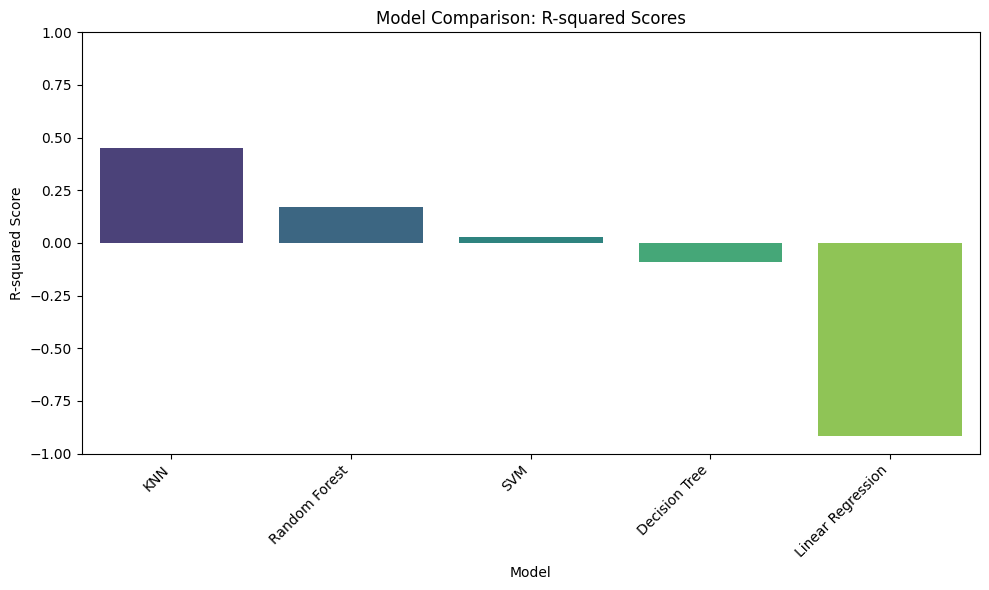

/tmp/ipykernel_5089/1200727825.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y='MAE', data=results_df.sort_values(by='MAE', ascending=True), palette='plasma')


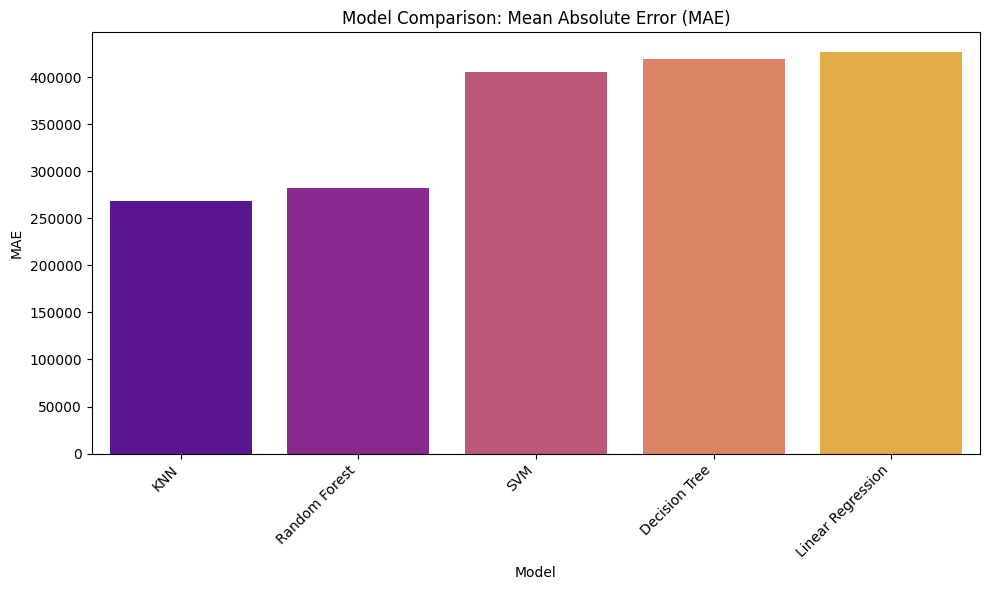

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

results_df = pd.DataFrame(model_results).T

# Plot R-squared scores
plt.figure(figsize=(10, 6))
sns.barplot(x=results_df.index, y='R2', data=results_df.sort_values(by='R2', ascending=False), palette='viridis')
plt.title('Model Comparison: R-squared Scores')
plt.xlabel('Model')
plt.ylabel('R-squared Score')
plt.xticks(rotation=45, ha='right')
plt.ylim(-1.0, 1.0) # R-squared can be negative
plt.tight_layout()
plt.show()

# Plot Mean Absolute Error (MAE)
plt.figure(figsize=(10, 6))
sns.barplot(x=results_df.index, y='MAE', data=results_df.sort_values(by='MAE', ascending=True), palette='plasma')
plt.title('Model Comparison: Mean Absolute Error (MAE)')
plt.xlabel('Model')
plt.ylabel('MAE')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [13]:
results_df.to_pickle('model_results.pkl')
print("model_results.pkl saved successfully.")

model_results.pkl saved successfully.
